In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score
from scipy.signal import periodogram

np.random.seed(123)

# Parâmetros das séries sintéticas
n_series_per_group = 8   # total ~ 32
T = 120                  # comprimento
t = np.arange(T)

def make_group_sine(freq, phase_jitter=0.0, amp=1.0, noise=0.3):
    series = []
    for _ in range(n_series_per_group):
        phase = np.random.uniform(-phase_jitter, phase_jitter)
        y = amp * np.sin(2*np.pi*freq*(t+phase)/T) + np.random.normal(0, noise, size=T)
        series.append(y)
    return np.array(series)

def make_group_trend(slope, noise=0.4):
    series = []
    for _ in range(n_series_per_group):
        bias = np.random.uniform(-2, 2)
        y = slope * t + bias + np.random.normal(0, noise, size=T)
        series.append(y)
    return np.array(series)

# 4 grupos: seno lento, seno rápido, tendência de alta e tendência de baixa
G1 = make_group_sine(freq=2, phase_jitter=6, amp=1.2, noise=0.25)
G2 = make_group_sine(freq=6, phase_jitter=6, amp=1.0, noise=0.25)
G3 = make_group_trend(slope=+0.05, noise=0.35)
G4 = make_group_trend(slope=-0.05, noise=0.35)

X_ts = np.vstack([G1, G2, G3, G4])  # shape: (N, T)
N = X_ts.shape[0]
print("Total de séries:", N, " | shape:", X_ts.shape)

Total de séries: 32  | shape: (32, 120)


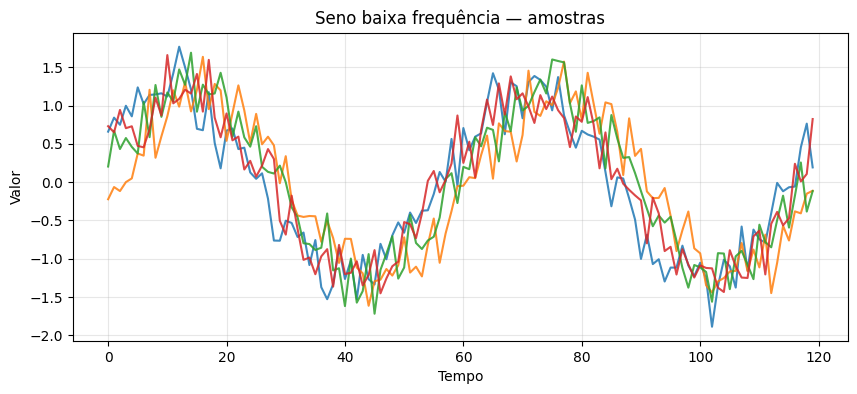

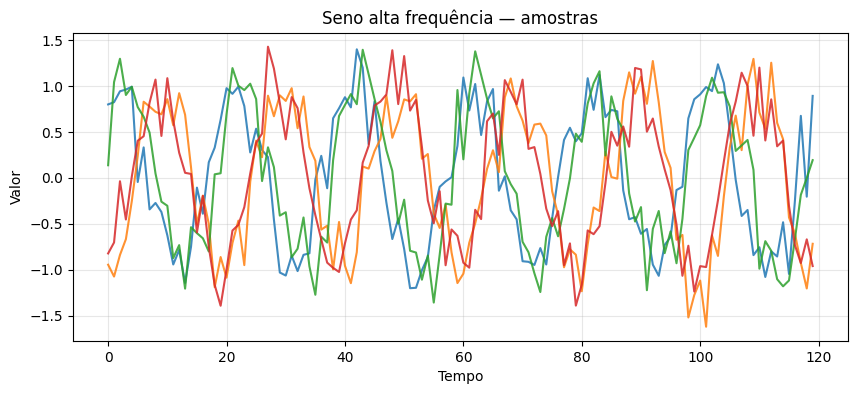

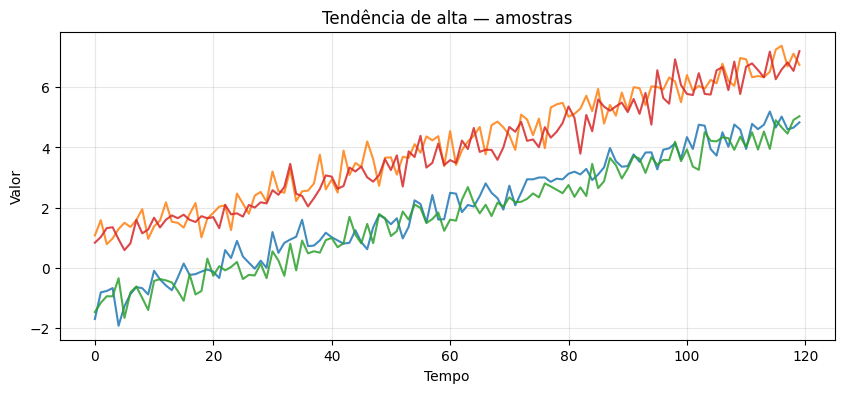

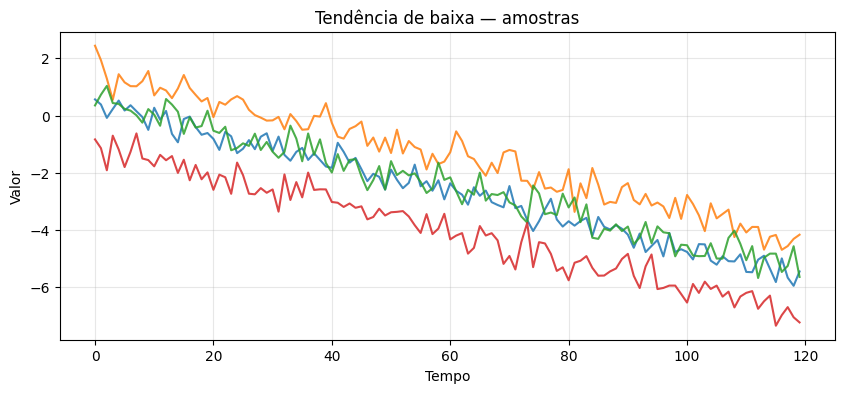

In [2]:
def plot_samples(X, n=4, title="Amostras"):
    plt.figure(figsize=(10, 4))
    idx = np.random.choice(len(X), size=n, replace=False)
    for i in idx:
        plt.plot(X[i], alpha=0.85)
    plt.title(title)
    plt.xlabel("Tempo")
    plt.ylabel("Valor")
    plt.grid(True, alpha=0.3)
    plt.show()

plot_samples(G1, title="Seno baixa frequência — amostras")
plot_samples(G2, title="Seno alta frequência — amostras")
plot_samples(G3, title="Tendência de alta — amostras")
plot_samples(G4, title="Tendência de baixa — amostras")

## Extração das *features* de séries temporais

Para agrupar séries temporais sem comparar diretamente ponto a ponto (como no DTW), podemos representar cada série por um **vetor de características (features)** que capture aspectos relevantes do seu comportamento global.  
As *features* usadas aqui são:

| Feature | Descrição | Interpretação |
|----------|------------|----------------|
| **mean** | Média dos valores da série. | Indica o **nível médio** da série (séries mais “altas” ou “baixas”). |
| **std** | Desvio padrão dos valores. | Mede a **variabilidade** da série — o quanto ela oscila ao redor da média. |
| **slope** | Inclinação da reta ajustada por regressão linear. | Captura **tendência global**: positiva (subindo), negativa (descendo) ou próxima de zero (estável). |
| **autocorr_lag1** | Autocorrelação com defasagem 1. | Mede quanto o valor atual se parece com o valor anterior. Séries **suaves** têm autocorrelação alta; séries **ruidosas**, baixa. |
| **dom_freq** | Frequência dominante (pico no espectro de Fourier). | Identifica **padrões periódicos**: séries com oscilações lentas terão frequência baixa; com oscilações rápidas, frequência alta. |

Essas *features* transformam cada série temporal (vetor de tamanho T) em um ponto num espaço de 5 dimensões — permitindo aplicar algoritmos tradicionais de agrupamento, como **K-means**.

Após a extração:
- As *features* são **padronizadas** (z-score) para evitar que diferenças de escala distorçam o agrupamento.  
- O K-means agrupa séries com perfis semelhantes em nível, variação, tendência e periodicidade.  
- Para interpretar os clusters, visualizamos a **média das séries de cada grupo** e observamos se representam padrões distintos (por exemplo: tendências crescentes, decrescentes, séries estáveis, séries oscilatórias, etc.).

In [ ]:
def slope_via_linreg(y):
    x = np.arange(len(y))
    x_mean, y_mean = x.mean(), y.mean()
    num = np.sum((x - x_mean) * (y - y_mean))
    den = np.sum((x - x_mean) ** 2) + 1e-12
    return num / den

def autocorr_lag1(y):
    y = y - y.mean()
    num = np.sum(y[1:] * y[:-1])
    den = np.sum(y[:-1] ** 2) + 1e-12
    return num / den

def dominant_freq(y, fs=1.0):
    f, Pxx = periodogram(y, fs=fs)
    if len(Pxx) > 1:
        idx = np.argmax(Pxx[1:]) + 1 
        return f[idx]
    return 0.0

def extract_features_matrix(X):
    feats = []
    for y in X:
        mean = np.mean(y)
        std = np.std(y)
        slp = slope_via_linreg(y)
        ac1 = autocorr_lag1(y)
        # normaliza antes de medir frequência dominante
        y_norm = (y - mean) / (std + 1e-12)
        domf = dominant_freq(y_norm, fs=1.0)
        feats.append([mean, std, slp, ac1, domf])
    return np.array(feats)

feat_names = ["mean", "std", "slope", "autocorr_lag1", "dom_freq"]
X_feat = extract_features_matrix(X_ts)
print("Features shape:", X_feat.shape, "|", feat_names)
X_feat[:3]

Features shape: (32, 5) | ['mean', 'std', 'slope', 'autocorr_lag1', 'dom_freq']


array([[ 0.00656037,  0.92910349, -0.00869349,  0.9260942 ,  0.01666667],
       [-0.01256178,  0.89444872, -0.00947002,  0.93954384,  0.01666667],
       [-0.01701495,  0.91005717, -0.00912804,  0.92945514,  0.01666667]])

## Medidas de avaliação interna: *Silhouette* e *Calinski–Harabasz (CH)*

Quando realizamos agrupamento (*clustering*), não temos rótulos verdadeiros para avaliar o resultado.  
Por isso usamos **métricas internas**, que avaliam o quão bem os clusters se separam e se mantêm coesos.

---

### Coeficiente de Silhouette (Silhueta)

- Mede **coesão** (o quão próximos os pontos de um mesmo cluster estão)  
  e **separação** (o quão distantes estão dos pontos de outros clusters).  
- O valor varia de **−1 a 1**:
  - **Próximo de 1:** o ponto está bem inserido em seu cluster e distante dos outros.  
  - **Próximo de 0:** o ponto está na fronteira entre clusters.  
  - **Negativo:** o ponto pode estar no cluster errado.

A média de todos os *silhouette scores* indica a **qualidade global da partição**.

> 💡 Regra prática: escolha o valor de `k` que **maximiza** o *Silhouette médio* —  
> mas também leve em conta a interpretabilidade dos clusters.

---

### Índice de Calinski–Harabasz (CH)

- Mede a razão entre a **dispersão entre clusters** e a **dispersão dentro dos clusters**:
  
  $$
  CH = \frac{\text{Variância entre clusters}}{\text{Variância dentro dos clusters}}
  $$

- Quanto maior o CH, melhor a separação entre os clusters e mais compactos eles são internamente.  
- Diferente do *Silhouette*, o CH não é limitado a um intervalo fixo.

Na prática: o `k` que **maximiza o CH** geralmente coincide com o melhor `k` pelo *Silhouette*.

---

### Interpretação conjunta
- Ambos os índices ajudam a **escolher o número ótimo de clusters (`k`)**.  
- Observe o formato das curvas (*Silhouette vs k*, *CH vs k*):  
  - um **pico** claro indica o `k` mais adequado;  
  - se os valores mudam pouco, o conjunto pode não ter estrutura de agrupamento clara.

Essas medidas não garantem um *k* "verdadeiro", mas ajudam a justificar a escolha de forma objetiva e quantitativa.

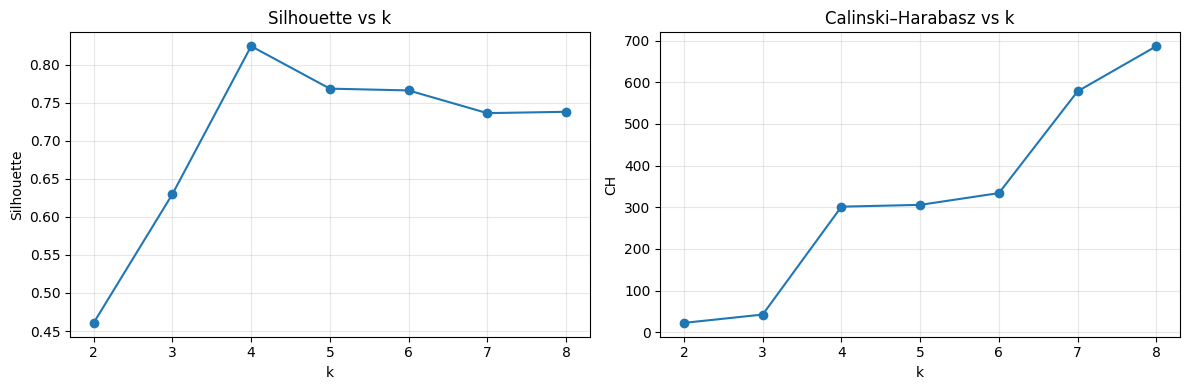

Melhor k (Silhouette): 4 | valor=0.824
Melhor k (CH)        : 8  | valor=686.6


In [4]:
scaler = StandardScaler()
Xz = scaler.fit_transform(X_feat)

k_range = range(2,  nine:=9)  # 2..8
sil_vals = []
ch_vals = []

for k in k_range:
    km = KMeans(n_clusters=k, n_init="auto", random_state=42)
    labels = km.fit_predict(Xz)
    sil_vals.append(silhouette_score(Xz, labels))
    ch_vals.append(calinski_harabasz_score(Xz, labels))

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
ax[0].plot(list(k_range), sil_vals, marker="o")
ax[0].set_title("Silhouette vs k")
ax[0].set_xlabel("k")
ax[0].set_ylabel("Silhouette")
ax[0].grid(True, alpha=0.3)

ax[1].plot(list(k_range), ch_vals, marker="o")
ax[1].set_title("Calinski–Harabasz vs k")
ax[1].set_xlabel("k")
ax[1].set_ylabel("CH")
ax[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

best_k_sil = list(k_range)[int(np.argmax(sil_vals))]
best_k_ch  = list(k_range)[int(np.argmax(ch_vals))]
print(f"Melhor k (Silhouette): {best_k_sil} | valor={max(sil_vals):.3f}")
print(f"Melhor k (CH)        : {best_k_ch}  | valor={max(ch_vals):.1f}")

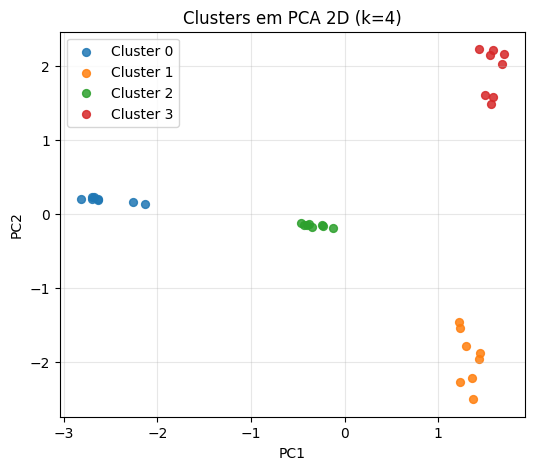

In [ ]:
# Escolha final de k — use a métrica que preferir (aqui, silhouette)
k = best_k_sil

km = KMeans(n_clusters=k, n_init="auto", random_state=42)
labels = km.fit_predict(Xz)

# PCA 2D apenas para visualização
pca = PCA(n_components=2, random_state=42)
XZ2 = pca.fit_transform(Xz)

plt.figure(figsize=(6, 5))
for c in range(k):
    plt.scatter(XZ2[labels == c, 0], XZ2[labels == c, 1], s=32, alpha=0.85, label=f"Cluster {c}")
plt.title(f"Clusters em PCA 2D (k={k})")
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

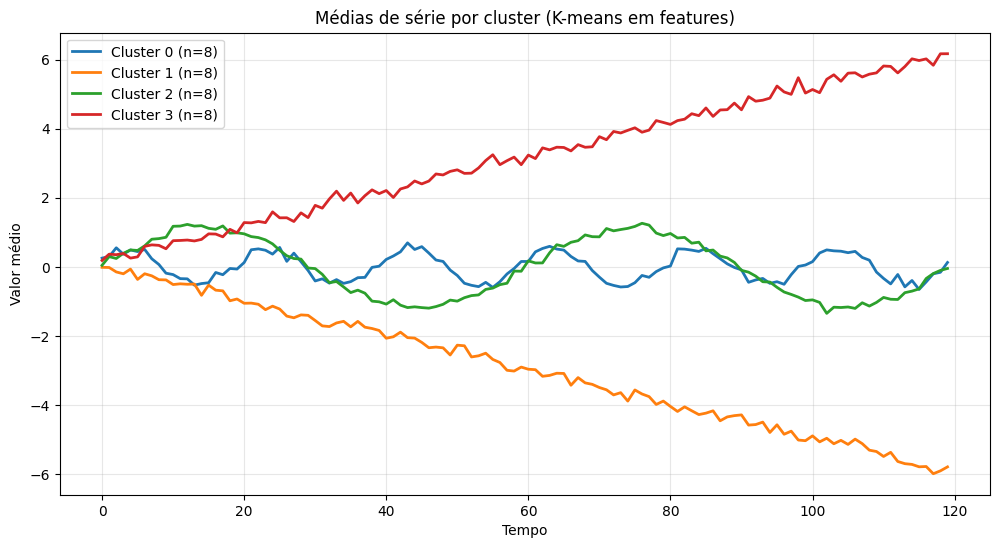

In [6]:
# %% [medias_por_cluster]
def plot_cluster_averages(X, labels, k, title="Médias por cluster"):
    plt.figure(figsize=(12, 6))
    for c in range(k):
        avg = X[labels == c].mean(axis=0)
        plt.plot(avg, linewidth=2, label=f"Cluster {c} (n={np.sum(labels==c)})")
    plt.title(title)
    plt.xlabel("Tempo")
    plt.ylabel("Valor médio")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

plot_cluster_averages(X_ts, labels, k, title="Médias de série por cluster (K-means em features)")

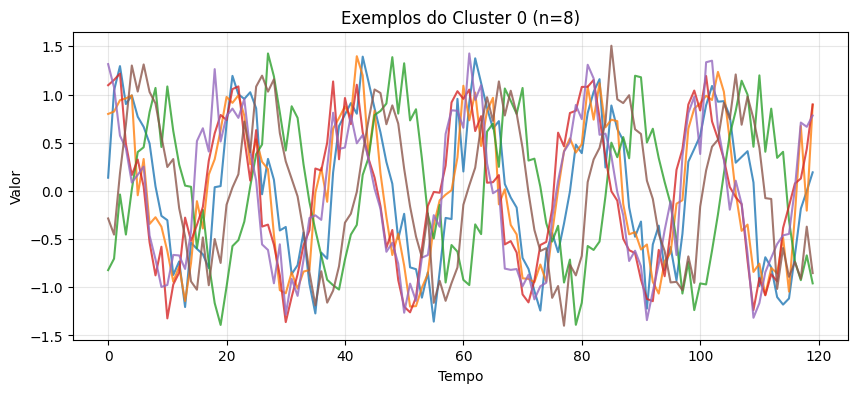

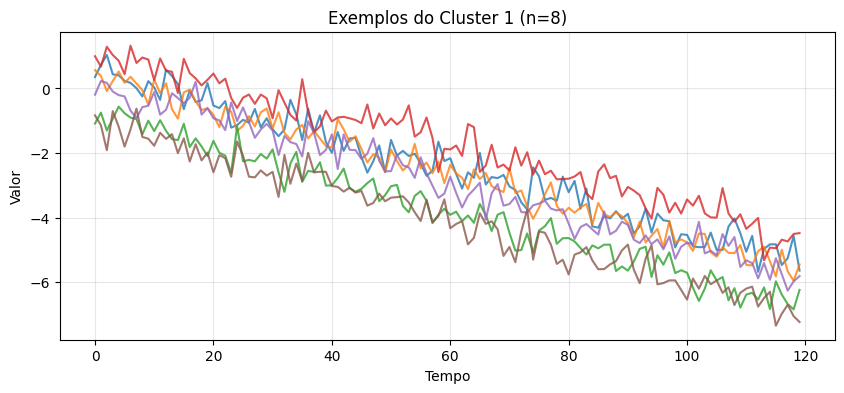

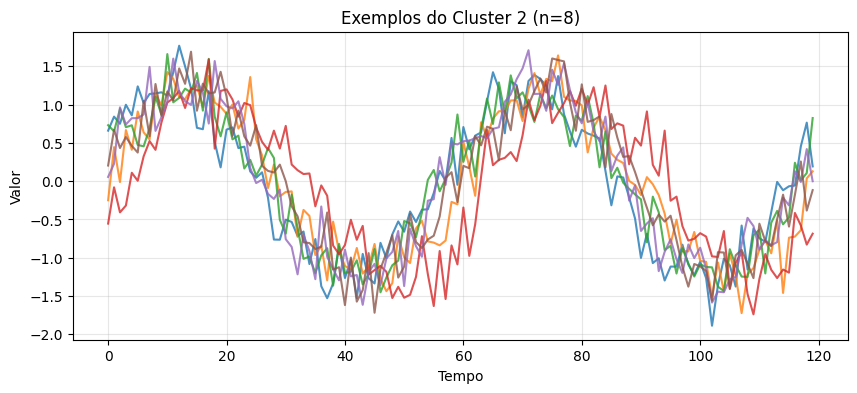

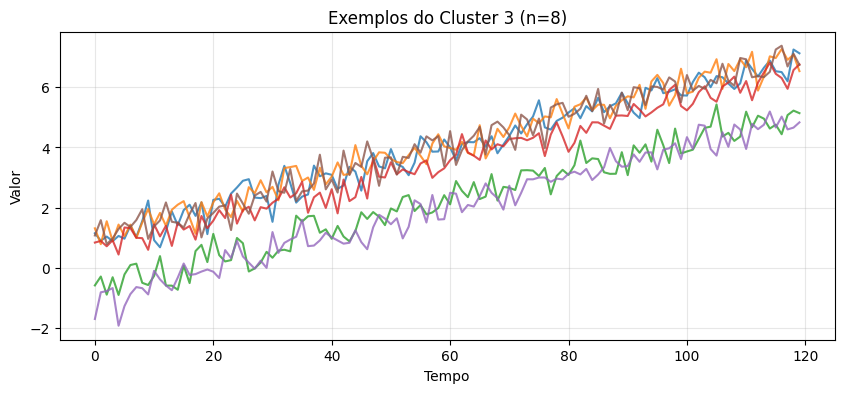

In [7]:
# %% [inspecionar_exemplos_por_cluster]
def plot_examples_by_cluster(X, labels, k, n_show=5):
    for c in range(k):
        idx = np.where(labels == c)[0]
        plt.figure(figsize=(10, 4))
        for i in np.random.choice(idx, size=min(n_show, len(idx)), replace=False):
            plt.plot(X[i], alpha=0.8)
        plt.title(f"Exemplos do Cluster {c} (n={len(idx)})")
        plt.xlabel("Tempo")
        plt.ylabel("Valor")
        plt.grid(True, alpha=0.3)
        plt.show()

plot_examples_by_cluster(X_ts, labels, k, n_show=6)

## Leitura dos resultados
- **mean/std** capturam nível e variabilidade; **slope** separa tendências ↑/↓.
- **autocorr_lag1** e **dom_freq** ajudam a separar padrões oscilatórios (baixa vs alta frequência).
- **Silhouette** e **CH** ajudam a escolher `k`. Use a forma das curvas e o contexto do problema (não só o máximo).